# Práctica 11 — Modelado y Sintonía PID de la Hielera

Este notebook toma los datos experimentales capturados por `11_logger.py` (respuesta al escalón de la hielera) e identifica su modelo dinámico como un **sistema de segundo orden sobreamortiguado**. Con ese modelo se calculan automáticamente los parámetros del controlador PID para la **práctica 12** usando el método **IMC (Internal Model Control)**.

**Flujo de trabajo:**
1. Cargar y visualizar el CSV de datos.
2. Ajustar el modelo matemático a los datos con `scipy.optimize.curve_fit`.
3. Calcular los parámetros PID mediante las reglas de sintonía IMC.
4. Mostrar todos los resultados en tablas y gráficas formateadas.

## 1. Importación de librerías

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display, Math, HTML

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 2. Carga y preprocesamiento de datos

El archivo `datos_hielera.csv` es generado por `11_logger.py` durante la simulación en Proteus. Contiene tres columnas:

| Columna | Descripción |
|---|---|
| `Tiempo_s` | Tiempo transcurrido desde el inicio (segundos) |
| `Temperatura_C` | Temperatura medida por el OVEN (°C) |
| `Entrada_PWM` | Señal de control enviada al MOSFET (0–255) |

El escalón de entrada se aplica a los **5 segundos**, por lo que filtramos los datos anteriores y calculamos el tiempo relativo $t' = t - 5$.

In [13]:
ARCHIVO_CSV    = 'datos_hielera.csv'
TIEMPO_ESCALON = 5.0    # segundos — debe coincidir con TIEMPO_ESCALON_S del .ino

df = pd.read_csv(ARCHIVO_CSV)
df.columns = ['Tiempo_s', 'Temperatura_C', 'Entrada_PWM']
df[['Tiempo_s', 'Temperatura_C', 'Entrada_PWM']] = df[['Tiempo_s', 'Temperatura_C', 'Entrada_PWM']].apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

# Detectar la amplitud del escalón directamente desde los datos
U_STEP     = int(df['Entrada_PWM'].max())          # valor máximo registrado en el CSV
U_STEP_PCT = round(U_STEP / 255 * 100, 1)          # porcentaje equivalente

# Columna en porcentaje para las gráficas
df['PWM_pct'] = df['Entrada_PWM'] / 255 * 100

print(f"Total de muestras: {len(df)}")
print(f"Rango de tiempo:   {df['Tiempo_s'].min():.1f} s  →  {df['Tiempo_s'].max():.1f} s")
print(f"Rango de T:        {df['Temperatura_C'].min():.2f} °C  →  {df['Temperatura_C'].max():.2f} °C")
print(f"Escalón PWM:       {U_STEP}/255  =  {U_STEP_PCT} %  (detectado automáticamente)\n")

display(HTML("<b>Primeras filas del dataset:</b>"))
display(df.head(8).style
        .format({'Tiempo_s': '{:.2f}', 'Temperatura_C': '{:.2f}', 'Entrada_PWM': '{:.0f}', 'PWM_pct': '{:.1f} %'})
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#4a7c9e'), ('color', 'white'), ('font-weight', 'bold')]}]))

# Filtrar post-escalón
df_escalon = df[df['Tiempo_s'] >= TIEMPO_ESCALON].copy()
df_escalon['Tiempo_Relativo'] = df_escalon['Tiempo_s'] - TIEMPO_ESCALON

t_exp = df_escalon['Tiempo_Relativo'].values
y_exp = df_escalon['Temperatura_C'].values
T_amb = float(y_exp[0])

Total de muestras: 1645
Rango de tiempo:   1.4 s  →  170.2 s
Rango de T:        24.93 °C  →  61.58 °C
Escalón PWM:       128/255  =  50.2 %  (detectado automáticamente)



,Tiempo_s,Temperatura_C,Entrada_PWM,PWM_pct
0,1.41,24.93,0,0.0 %
1,1.52,24.93,0,0.0 %
2,1.62,24.93,0,0.0 %
3,1.72,24.93,0,0.0 %
4,1.82,24.93,0,0.0 %
5,1.92,24.93,0,0.0 %
6,2.02,24.93,0,0.0 %
7,2.12,24.93,0,0.0 %


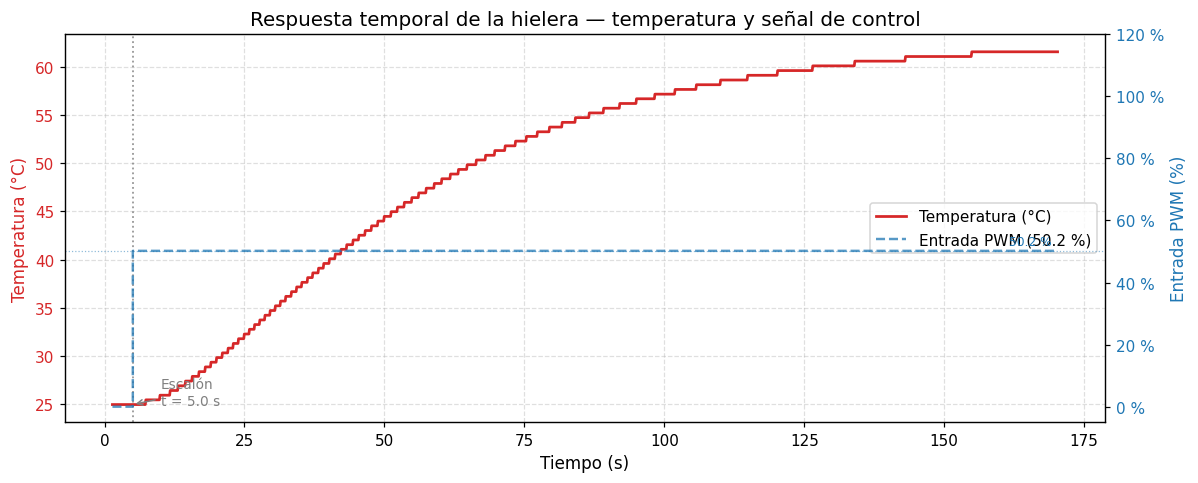

In [14]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))

# --- Eje izquierdo: Temperatura ---
ax1.plot(df['Tiempo_s'], df['Temperatura_C'], color='#d62728', linewidth=1.8, label='Temperatura (°C)')
ax1.set_xlabel('Tiempo (s)', fontsize=11)
ax1.set_ylabel('Temperatura (°C)', color='#d62728', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#d62728')

# Línea vertical del escalón
ax1.axvline(TIEMPO_ESCALON, color='gray', linestyle=':', linewidth=1.2, alpha=0.8)
ax1.annotate(
    f'Escalón\nt = {TIEMPO_ESCALON} s',
    xy=(TIEMPO_ESCALON, df['Temperatura_C'].min()),
    xytext=(TIEMPO_ESCALON + (df['Tiempo_s'].max() * 0.03), df['Temperatura_C'].min()),
    color='gray', fontsize=9,
    arrowprops=dict(arrowstyle='->', color='gray'),
)

# --- Eje derecho: PWM en % ---
ax2 = ax1.twinx()
ax2.step(df['Tiempo_s'], df['PWM_pct'], color='#1f77b4', linewidth=1.6,
         where='post', linestyle='--', alpha=0.75, label=f'Entrada PWM ({U_STEP_PCT} %)')
ax2.set_ylabel('Entrada PWM (%)', color='#1f77b4', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#1f77b4')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f} %'))
ax2.set_ylim(-5, 120)

# Línea horizontal de referencia del escalón
ax2.axhline(U_STEP_PCT, color='#1f77b4', linestyle=':', linewidth=0.8, alpha=0.5)
ax2.annotate(f'{U_STEP_PCT} %', xy=(df['Tiempo_s'].max(), U_STEP_PCT),
             xytext=(-4, 4), textcoords='offset points',
             color='#1f77b4', fontsize=8, ha='right')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

ax1.set_title('Respuesta temporal de la hielera — temperatura y señal de control', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Modelo matemático — Sistema de 2.° orden sobreamortiguado

La hielera se modela como **dos primeros órdenes en cascada**: uno representa la inercia térmica del recinto y el otro la dinámica del sensor / bombilla. En el dominio de Laplace, la función de transferencia es:

$$G(s) = \frac{K}{(\tau_1 s + 1)(\tau_2 s + 1)}$$

donde:
- $K$ — ganancia estática del sistema $\left[\dfrac{°\text{C}}{\text{PWM}}\right]$
- $\tau_1$ — constante de tiempo dominante (hielera) $[\text{s}]$
- $\tau_2$ — constante de tiempo secundaria (sensor/bombilla) $[\text{s}]$, con $\tau_1 > \tau_2$

Para una entrada escalón de amplitud $U$ (PWM = 255), la respuesta en el tiempo con condición inicial $T_\text{amb}$ es:

$$y(t) = T_\text{amb} + K \cdot U \left(1 - \frac{\tau_1\, e^{-t/\tau_1} - \tau_2\, e^{-t/\tau_2}}{\tau_1 - \tau_2}\right)$$

In [15]:
def respuesta_segundo_orden(t, K, tau1, tau2):
    """Respuesta al escalón de un sistema de 2.° orden sobreamortiguado."""
    if np.abs(tau1 - tau2) < 1e-4:
        tau2 += 1e-3   # evitar singularidad numérica
    return T_amb + K * U_STEP * (
        1.0 - (tau1 * np.exp(-t / tau1) - tau2 * np.exp(-t / tau2)) / (tau1 - tau2)
    )

# Mostrar la ecuación con LaTeX usando display()
display(Math(
    r"y(t) = T_{\mathrm{amb}} + K \cdot U \left(1 - "
    r"\frac{\tau_1\, e^{-t/\tau_1} - \tau_2\, e^{-t/\tau_2}}{\tau_1 - \tau_2}\right)"
))
print("Función definida ✓")

<IPython.core.display.Math object>

Función definida ✓


## 4. Ajuste de curvas — Identificación del sistema

`scipy.optimize.curve_fit` ajusta los parámetros $(K, \tau_1, \tau_2)$ minimizando el error cuadrático entre el modelo y los datos experimentales.

**Estimaciones iniciales:**
- $K_0 = (T_\text{max} - T_\text{amb}) \,/\, U$ — ganancia aproximada por la variación total observada.
- $\tau_1 \approx 40\ \text{s}$, $\tau_2 \approx 15\ \text{s}$ — valores típicos para una hielera pequeña.

In [16]:
K_guess = (float(y_exp[-1]) - T_amb) / U_STEP

popt, pcov = curve_fit(
    respuesta_segundo_orden,
    t_exp, y_exp,
    p0=[K_guess, 40.0, 15.0],
    bounds=(0, np.inf),
    maxfev=10000,
)
K_est, tau1_est, tau2_est = popt
perr = np.sqrt(np.diag(pcov))

# Mostrar parámetros con LaTeX
display(Math(rf"K = {K_est:.5f}\ \frac{{°C}}{{\mathrm{{PWM}}}}"))
display(Math(rf"\tau_1 = {tau1_est:.2f}\ \mathrm{{s}}"))
display(Math(rf"\tau_2 = {tau2_est:.2f}\ \mathrm{{s}}"))

# Bondad del ajuste (R²)
y_pred = respuesta_segundo_orden(t_exp, *popt)
ss_res = np.sum((y_exp - y_pred) ** 2)
ss_tot = np.sum((y_exp - np.mean(y_exp)) ** 2)
r2 = 1 - ss_res / ss_tot
display(Math(rf"R^2 = {r2:.6f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 5. Sintonía PID por método IMC

El método **IMC (Internal Model Control)** proporciona fórmulas analíticas directas a partir del modelo identificado. El único parámetro de diseño es $\lambda$ (constante de tiempo de lazo cerrado deseada). Una regla práctica robusta es:

$$\lambda = \frac{\tau_1}{3}$$

Con ese valor, los parámetros del controlador PID en la forma **paralela** son:

$$K_p = \frac{\tau_1 + \tau_2}{K \cdot \lambda}
\qquad
T_i = \tau_1 + \tau_2
\qquad
T_d = \frac{\tau_1 \tau_2}{\tau_1 + \tau_2}$$

$$K_i = \frac{K_p}{T_i}
\qquad
K_d = K_p \cdot T_d$$

> Un $\lambda$ más pequeño da respuesta más rápida pero menos robusta al ruido. Un $\lambda$ más grande da respuesta más suave.

In [17]:
lambda_cl = tau1_est / 3.0

Kp  = (tau1_est + tau2_est) / (K_est * lambda_cl)
Ti  = tau1_est + tau2_est
Td  = (tau1_est * tau2_est) / (tau1_est + tau2_est)
Ki  = Kp / Ti
Kd  = Kp * Td

# Ecuaciones con valores numéricos sustituidos
display(Math(rf"\lambda = \frac{{\tau_1}}{{3}} = \frac{{{tau1_est:.2f}}}{{3}} = {lambda_cl:.2f}\ \mathrm{{s}}"))
display(Math(rf"K_p = \frac{{\tau_1 + \tau_2}}{{K \cdot \lambda}} = \frac{{{tau1_est:.2f} + {tau2_est:.2f}}}{{{K_est:.5f} \cdot {lambda_cl:.2f}}} = {Kp:.4f}"))
display(Math(rf"T_i = \tau_1 + \tau_2 = {tau1_est:.2f} + {tau2_est:.2f} = {Ti:.2f}\ \mathrm{{s}}"))
display(Math(rf"T_d = \frac{{\tau_1 \tau_2}}{{\tau_1+\tau_2}} = \frac{{{tau1_est:.2f} \cdot {tau2_est:.2f}}}{{{tau1_est:.2f}+{tau2_est:.2f}}} = {Td:.4f}\ \mathrm{{s}}"))
display(Math(rf"K_i = \frac{{K_p}}{{T_i}} = \frac{{{Kp:.4f}}}{{{Ti:.2f}}} = {Ki:.6f}"))
display(Math(rf"K_d = K_p \cdot T_d = {Kp:.4f} \cdot {Td:.4f} = {Kd:.4f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 6. Tablas de resultados

In [18]:
HEADER_STYLE = [
    {'selector': 'th', 'props': [
        ('background-color', '#2c5f7a'), ('color', 'white'),
        ('font-weight', 'bold'), ('text-align', 'center'),
    ]},
    {'selector': 'td', 'props': [('text-align', 'center')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#eaf4fb')]},
]

# --- Tabla 1: Parámetros del sistema identificado ---
df_sistema = pd.DataFrame({
    'Parámetro': ['K', 'τ₁', 'τ₂', 'λ (IMC)', 'T_amb', 'R²'],
    'Descripción': [
        'Ganancia estática',
        'Constante de tiempo dominante (hielera)',
        'Constante de tiempo secundaria (sensor/bombilla)',
        'Constante de lazo cerrado (diseño)',
        'Temperatura inicial',
        'Coeficiente de determinación del ajuste',
    ],
    'Valor': [
        f'{K_est:.5f} °C/PWM',
        f'{tau1_est:.2f} s',
        f'{tau2_est:.2f} s',
        f'{lambda_cl:.2f} s',
        f'{T_amb:.2f} °C',
        f'{r2:.6f}',
    ],
})

display(HTML("<b>Parámetros del sistema identificado:</b>"))
display(df_sistema.style.set_table_styles(HEADER_STYLE).hide(axis='index'))

print()

# --- Tabla 2: Parámetros del controlador PID ---
df_pid = pd.DataFrame({
    'Parámetro': ['Kp', 'Ki', 'Kd', 'Ti', 'Td'],
    'Descripción': [
        'Ganancia proporcional',
        'Ganancia integral',
        'Ganancia derivativa',
        'Tiempo integral',
        'Tiempo derivativo',
    ],
    'Valor': [
        f'{Kp:.4f}',
        f'{Ki:.6f}',
        f'{Kd:.4f}',
        f'{Ti:.2f} s',
        f'{Td:.4f} s',
    ],
})

display(HTML("<b>Parámetros del controlador PID (forma paralela) — para la práctica 12:</b>"))
display(df_pid.style.set_table_styles(HEADER_STYLE).hide(axis='index'))

Parámetro,Descripción,Valor
K,Ganancia estática,0.29550 °C/PWM
τ₁,Constante de tiempo dominante (hielera),40.08 s
τ₂,Constante de tiempo secundaria (sensor/bombilla),14.86 s
λ (IMC),Constante de lazo cerrado (diseño),13.36 s
T_amb,Temperatura inicial,24.93 °C
R²,Coeficiente de determinación del ajuste,0.999850


Parámetro,Descripción,Valor
Kp,Ganancia proporcional,13.9166
Ki,Ganancia integral,0.253325
Kd,Ganancia derivativa,150.8610
Ti,Tiempo integral,54.94 s
Td,Tiempo derivativo,10.8404 s


## 7. Gráfica de identificación

Se superponen los datos experimentales (puntos) con la curva del modelo ajustado (línea continua). Una buena identificación se observa cuando ambas se solapan estrechamente y el valor de $R^2$ es cercano a 1.

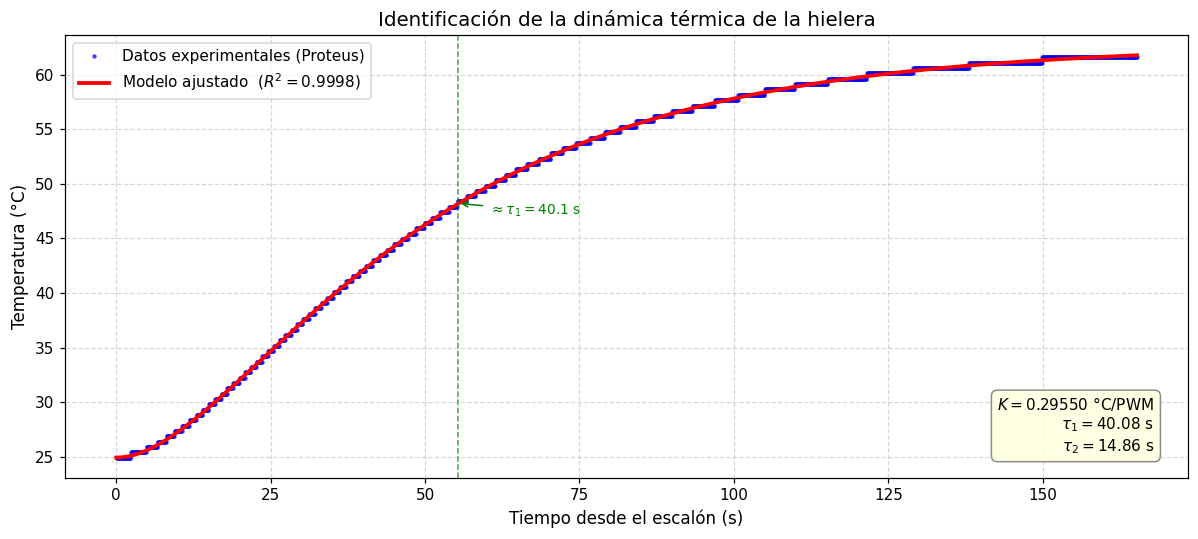

In [19]:
t_modelo = np.linspace(0, t_exp[-1], 500)
y_modelo = respuesta_segundo_orden(t_modelo, *popt)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(t_exp, y_exp, 'b.', markersize=4, alpha=0.6, label='Datos experimentales (Proteus)')
ax.plot(t_modelo, y_modelo, 'r-', linewidth=2.5, label=f'Modelo ajustado  ($R^2={r2:.4f}$)')

# Anotaciones de los parámetros identificados
info = (
    f"$K = {K_est:.5f}$ °C/PWM\n"
    f"$\\tau_1 = {tau1_est:.2f}$ s\n"
    f"$\\tau_2 = {tau2_est:.2f}$ s"
)
ax.annotate(
    info, xy=(0.97, 0.05), xycoords='axes fraction',
    ha='right', va='bottom', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray', alpha=0.9),
)

# Marcar tau1 en la curva (63.2% de la variación total)
delta_T = y_modelo[-1] - T_amb
T_tau1 = T_amb + 0.632 * delta_T
idx_tau1 = np.argmin(np.abs(y_modelo - T_tau1))
ax.axvline(t_modelo[idx_tau1], color='green', linestyle='--', linewidth=1, alpha=0.7)
ax.annotate(
    f'$\\approx\\tau_1 = {tau1_est:.1f}$ s',
    xy=(t_modelo[idx_tau1], T_tau1),
    xytext=(t_modelo[idx_tau1] + 5, T_tau1 - 1),
    arrowprops=dict(arrowstyle='->', color='green'),
    color='green', fontsize=9,
)

ax.set_title('Identificación de la dinámica térmica de la hielera', fontsize=13)
ax.set_xlabel('Tiempo desde el escalón (s)', fontsize=11)
ax.set_ylabel('Temperatura (°C)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()